In [18]:
import os
import math
import pandas as pd
import sqlite3

pd.set_option('future.no_silent_downcasting', True)

_DB_PATH = os.path.join(os.getcwd(), "../../data/ai_audit_db.sqlite")


# ─────────────────────────────────────────────────────────────────────────────
# Database Helper
# ─────────────────────────────────────────────────────────────────────────────
def get_data_from_db(query: str) -> pd.DataFrame:
    """Execute a SQL query and return results as a DataFrame."""
    try:
        conn = sqlite3.connect(_DB_PATH, timeout=30)
        df = pd.read_sql_query(query, conn)
        conn.close()
        return df
    except Exception as e:
        print(f"❌ Error reading from database: {e}")
        return pd.DataFrame()


# ─────────────────────────────────────────────────────────────────────────────
# 1. Revenue Features
# ─────────────────────────────────────────────────────────────────────────────
def Revenue_Features() -> pd.DataFrame:
    """Monthly revenue with lags, rolling stats, and calendar encodings."""
    revenue_by_month = get_data_from_db("""
        SELECT SUM(total_amount) AS total,
               strftime('%Y-%m', invoice_date) AS month
        FROM invoices
        WHERE type = 'out_invoice'
        GROUP BY month
    """)

    if revenue_by_month.empty:
        raise ValueError("Revenue_Features: No invoice data found.")

    revenue_by_month['month'] = pd.to_datetime(revenue_by_month['month'])
    revenue_by_month = revenue_by_month.sort_values('month').reset_index(drop=True)

    # Lags & rolling stats (Month-over-Month only; YoY removed due to short history)
    revenue_by_month['revenue_lag_1']      = revenue_by_month['total'].shift(1)
    revenue_by_month['revenue_lag_3']      = revenue_by_month['total'].shift(3)
    revenue_by_month['revenue_growth_mom'] = revenue_by_month['total'].pct_change(1)
    revenue_by_month['revenue_ma_3']       = revenue_by_month['total'].rolling(3).mean()
    revenue_by_month['revenue_ma_6']       = revenue_by_month['total'].rolling(6).mean()
    revenue_by_month['revenue_std_3']      = revenue_by_month['total'].rolling(3).std()

    # Calendar features
    revenue_by_month['month_num']   = revenue_by_month['month'].dt.month
    revenue_by_month['quarter']     = revenue_by_month['month'].dt.quarter
    revenue_by_month['month_sin']   = (revenue_by_month['month_num'] * 2 * math.pi / 12).apply(math.sin)
    revenue_by_month['month_cos']   = (revenue_by_month['month_num'] * 2 * math.pi / 12).apply(math.cos)
    revenue_by_month['is_year_end'] = revenue_by_month['month_num'].isin([11, 12]).astype(int)

    revenue_by_month['month'] = revenue_by_month['month'].dt.strftime('%Y-%m')

    print("✅ Revenue Features:")
    print(revenue_by_month[['month', 'total', 'revenue_growth_mom', 'revenue_ma_3', 'revenue_std_3']].tail())
    return revenue_by_month


# ─────────────────────────────────────────────────────────────────────────────
# 2. COGS & Operating Expenses
# ─────────────────────────────────────────────────────────────────────────────
def cogs_expenses_features(features_df: pd.DataFrame = None) -> pd.DataFrame:
    """
    Add:
      - COGS calculated from sold items (quantity * product.cost)
      - Operating expenses from journal entries (account type = 'expense')
    """
    if features_df is None:
        features_df = Revenue_Features()

    # COGS = cost of goods actually SOLD (matched to revenue month)
    monthly_cogs = get_data_from_db("""
        SELECT strftime('%Y-%m', inv.invoice_date) AS month,
               SUM(il.quantity * p.cost) AS total_cogs
        FROM invoice_lines il
        JOIN invoices inv ON il.invoice_id = inv.id
        JOIN products p   ON il.product_id = p.id
        WHERE inv.type = 'out_invoice'
        GROUP BY month
    """)

    if monthly_cogs.empty:
        print("⚠️  Warning: No COGS data found. Check products.cost values.")
        monthly_cogs = pd.DataFrame(columns=['month', 'total_cogs'])

    # Operating Expenses (excluding COGS – only 'expense' accounts)
    monthly_expenses = get_data_from_db("""
        SELECT strftime('%Y-%m', je.entry_date) AS month,
               SUM(jl.debit) - SUM(jl.credit) AS total_expenses
        FROM journal_lines jl
        JOIN journal_entries je ON jl.journal_entry_id = je.id
        JOIN accounts a ON jl.account_id = a.id
        WHERE a.type = 'expense'
        GROUP BY month
    """)

    if monthly_expenses.empty:
        print("⚠️  Warning: No expense journal entries found.")
        monthly_expenses = pd.DataFrame(columns=['month', 'total_expenses'])

    # Merge into feature set
    features_df = (
        features_df.rename(columns={'total': 'monthly_revenue'})
        .merge(monthly_cogs, on='month', how='left')
        .merge(monthly_expenses, on='month', how='left')
    )

    # Check for missing COGS (possible data integrity issue)
    if features_df['total_cogs'].isna().any():
        missing_months = features_df.loc[features_df['total_cogs'].isna(), 'month'].tolist()
        print(f"⚠️  Warning: COGS missing for months: {missing_months}. Filling with 0.")
        features_df['total_cogs'] = features_df['total_cogs'].fillna(0)
    else:
        features_df['total_cogs'] = features_df['total_cogs'].fillna(0).infer_objects(copy=False)

    features_df['total_expenses'] = features_df['total_expenses'].fillna(0).infer_objects(copy=False)

    # Ratios
    features_df['cogs_to_revenue_ratio'] = (
        features_df['total_cogs'] / features_df['monthly_revenue'].replace(0, pd.NA)
    )
    features_df['expense_ratio'] = (
        features_df['total_expenses'] / features_df['monthly_revenue'].replace(0, pd.NA)
    )

    print("\n✅ COGS & Expenses Features:")
    print(features_df[['month', 'monthly_revenue', 'total_cogs', 'cogs_to_revenue_ratio', 'expense_ratio']].tail())
    return features_df


# ─────────────────────────────────────────────────────────────────────────────
# 3. Unit Economics
# ─────────────────────────────────────────────────────────────────────────────
def Unit_Economics_Features(features_df: pd.DataFrame = None) -> pd.DataFrame:
    """Gross margin, weighted average margin, and margin volatility."""
    if features_df is None:
        features_df = cogs_expenses_features()

    # Gross margin from total revenue and COGS
    features_df['gross_margin'] = (
        (features_df['monthly_revenue'] - features_df['total_cogs'])
        / features_df['monthly_revenue'].replace(0, pd.NA)
    )

    # Weighted average margin per invoice line (for product‑mix insight)
    monthly_margin = get_data_from_db("""
        SELECT strftime('%Y-%m', inv.invoice_date) AS month,
               SUM(il.quantity * (il.unit_price - p.cost))
               / NULLIF(SUM(il.quantity * il.unit_price), 0) AS weighted_avg_margin
        FROM invoice_lines il
        JOIN invoices inv ON il.invoice_id = inv.id
        JOIN products p   ON il.product_id = p.id
        WHERE inv.type = 'out_invoice'
        GROUP BY month
    """)

    if not monthly_margin.empty:
        features_df = features_df.merge(monthly_margin, on='month', how='left')

    print("\n✅ Unit Economics Features:")
    print(features_df[['month', 'gross_margin', 'weighted_avg_margin']].tail())
    return features_df


# ─────────────────────────────────────────────────────────────────────────────
# 4. Cash Flow & Collection Metrics
# ─────────────────────────────────────────────────────────────────────────────
def Cash_Flow_Features(features_df: pd.DataFrame = None) -> pd.DataFrame:
    """DSO, overdue ratio, collection gap, and payment method mix."""
    if features_df is None:
        features_df = Unit_Economics_Features()

    # Days Sales Outstanding (DSO)
    dso_df = get_data_from_db("""
        SELECT strftime('%Y-%m', i.invoice_date) AS month,
               AVG(julianday(p.payment_date) - julianday(i.invoice_date)) AS dso_days
        FROM invoices i
        JOIN payments p ON i.id = p.invoice_id
        WHERE i.type = 'out_invoice'
        GROUP BY month
    """)

    # Overdue amount and ratio
    overdue_df = get_data_from_db("""
        SELECT strftime('%Y-%m', i.invoice_date) AS month,
               SUM(CASE
                    WHEN p.payment_date IS NULL
                      OR julianday(p.payment_date) > julianday(i.due_date)
                    THEN i.total_amount ELSE 0
               END) AS overdue_amount,
               SUM(i.total_amount) AS total_invoiced
        FROM invoices i
        LEFT JOIN payments p ON i.id = p.invoice_id
        WHERE i.type = 'out_invoice'
        GROUP BY month
    """)

    if not overdue_df.empty:
        overdue_df['overdue_ratio'] = (
            overdue_df['overdue_amount'] / overdue_df['total_invoiced'].replace(0, pd.NA)
        )

    # Billed vs Collected in same month
    billed_collected_df = get_data_from_db("""
        SELECT month,
               SUM(billed_this_month)    AS billed_this_month,
               SUM(collected_this_month) AS collected_this_month
        FROM (
            SELECT strftime('%Y-%m', invoice_date) AS month,
                   total_amount AS billed_this_month,
                   0            AS collected_this_month
            FROM invoices WHERE type = 'out_invoice'
            UNION ALL
            SELECT strftime('%Y-%m', p.payment_date) AS month,
                   0         AS billed_this_month,
                   p.amount  AS collected_this_month
            FROM payments p
            JOIN invoices i ON p.invoice_id = i.id
            WHERE i.type = 'out_invoice'
        )
        WHERE month IS NOT NULL
        GROUP BY month
    """)

    # Payment method percentages
    payment_method_df = get_data_from_db("""
        SELECT strftime('%Y-%m', p.payment_date) AS month,
               SUM(CASE WHEN LOWER(p.payment_method) LIKE '%cash%'
                        THEN p.amount ELSE 0 END)
               / NULLIF(SUM(p.amount), 0) AS pct_paid_cash,
               SUM(CASE WHEN LOWER(p.payment_method) LIKE '%credit%'
                          OR LOWER(p.payment_method) LIKE '%card%'
                        THEN p.amount ELSE 0 END)
               / NULLIF(SUM(p.amount), 0) AS pct_paid_credit
        FROM payments p
        JOIN invoices i ON p.invoice_id = i.id
        WHERE i.type = 'out_invoice'
        GROUP BY month
    """)

    # Merge all cash flow features (NO lags yet)
    features_df = features_df.merge(dso_df, on='month', how='left')

    if not overdue_df.empty:
        features_df = features_df.merge(overdue_df[['month', 'overdue_amount', 'overdue_ratio']],
                                        on='month', how='left')

    if not billed_collected_df.empty:
        features_df = features_df.merge(billed_collected_df, on='month', how='left')
        # Compute collection gap and its lag AFTER merging (ensuring continuous timeline)
        features_df['collection_gap'] = (
            features_df['billed_this_month'] - features_df['collected_this_month']
        )
        features_df['collection_gap_lag_1'] = features_df['collection_gap'].shift(1)

    if not payment_method_df.empty:
        features_df = features_df.merge(payment_method_df, on='month', how='left')

    print("\n✅ Cash Flow Features:")
    print(features_df[['month', 'dso_days', 'overdue_ratio', 'collection_gap', 'pct_paid_cash']].tail())
    return features_df


# ─────────────────────────────────────────────────────────────────────────────
# 5. Volume, Customer Concentration & Purchase Order Activity
# ─────────────────────────────────────────────────────────────────────────────
def Volume_Activity_Features(features_df: pd.DataFrame = None) -> pd.DataFrame:
    """Invoice volume, customer concentration, and purchase order trends."""
    if features_df is None:
        features_df = Cash_Flow_Features()

    # Transaction volume – FIXED: use customer_id for sales invoices
    tx_volume_df = get_data_from_db("""
        SELECT strftime('%Y-%m', invoice_date) AS month,
               COUNT(*)                        AS invoice_count,
               AVG(total_amount)               AS avg_invoice_value,
               COUNT(DISTINCT customer_id)     AS unique_customers
        FROM invoices
        WHERE type = 'out_invoice'
        GROUP BY month
    """)

    # Customer concentration (top 1 and top 3 customers share of revenue)
    concentration_df = get_data_from_db("""
        WITH MonthlyRevenue AS (
            SELECT strftime('%Y-%m', invoice_date) AS month,
                   customer_id,
                   SUM(total_amount) AS customer_revenue
            FROM invoices
            WHERE type = 'out_invoice'
            GROUP BY month, customer_id
        ),
        TotalPerMonth AS (
            SELECT month, SUM(customer_revenue) AS total_revenue
            FROM MonthlyRevenue
            GROUP BY month
        ),
        RankedRevenue AS (
            SELECT m.month,
                   m.customer_revenue,
                   t.total_revenue,
                   ROW_NUMBER() OVER (PARTITION BY m.month ORDER BY m.customer_revenue DESC) AS rank
            FROM MonthlyRevenue m
            JOIN TotalPerMonth t ON m.month = t.month
        )
        SELECT month,
               SUM(CASE WHEN rank = 1  THEN customer_revenue ELSE 0 END)
               / NULLIF(MAX(total_revenue), 0) AS top1_customer_pct,
               SUM(CASE WHEN rank <= 3 THEN customer_revenue ELSE 0 END)
               / NULLIF(MAX(total_revenue), 0) AS top3_customers_pct
        FROM RankedRevenue
        GROUP BY month
    """)

    # Purchase order activity (for inventory planning, NOT for COGS)
    po_df = get_data_from_db("""
        SELECT strftime('%Y-%m', order_date) AS month,
               COUNT(*)           AS po_count,
               SUM(total_amount)  AS po_total_value
        FROM purchase_orders
        WHERE status = 'done'
        GROUP BY month
    """)

    # Merge all volume/activity data (NO lags yet)
    features_df = features_df.merge(tx_volume_df, on='month', how='left')
    features_df = features_df.merge(concentration_df, on='month', how='left')
    features_df = features_df.merge(po_df, on='month', how='left')

    # Compute PO lag AFTER merging (ensures continuous timeline)
    if not po_df.empty:
        features_df['po_lag_1'] = features_df['po_total_value'].shift(1)

    # Lags for unit economics and cash flow (now on the full DataFrame)
    features_df['gross_margin_lag_1'] = features_df['gross_margin'].shift(1)
    features_df['gross_margin_ma_3']  = features_df['gross_margin'].rolling(3).mean()
    features_df['margin_delta_mom']   = features_df['gross_margin'].diff(1)

    features_df['cogs_lag_1']      = features_df['total_cogs'].shift(1)
    features_df['cogs_lag_3']      = features_df['total_cogs'].shift(3)
    features_df['expense_lag_1']   = features_df['total_expenses'].shift(1)
    features_df['cogs_growth_mom'] = features_df['total_cogs'].pct_change(1)

    # Net profit (Revenue - COGS - Operating Expenses)
    features_df['net_profit'] = (
        features_df['monthly_revenue']
        - features_df['total_cogs']
        - features_df['total_expenses']
    )

    # Target: next month's net profit (shift backwards)
    features_df['target_profit'] = features_df['net_profit'].shift(-1)
    features_df = features_df.dropna(subset=['target_profit'])

    print("\n✅ Volume & Activity Features:")
    print(features_df[['month', 'invoice_count', 'unique_customers', 'top1_customer_pct', 'po_total_value']].tail())
    return features_df


# ─────────────────────────────────────────────────────────────────────────────
# Orchestrator
# ─────────────────────────────────────────────────────────────────────────────
def build_feature_pipeline() -> pd.DataFrame:
    """Run the complete feature pipeline and return the final DataFrame."""
    print("=" * 60)
    print("🚀 Running feature engineering pipeline...")
    print("=" * 60)

    revenue_df = Revenue_Features()
    features_df = cogs_expenses_features(revenue_df)
    features_df = Unit_Economics_Features(features_df)
    features_df = Cash_Flow_Features(features_df)
    features_df = Volume_Activity_Features(features_df)

    print("\n" + "=" * 60)
    print(f"✅ Pipeline complete. Shape: {features_df.shape}")
    print(f"📊 Columns ({len(features_df.columns)}): {list(features_df.columns)}")
    print("=" * 60)

    return features_df




📦 Loading feature pipeline...

✅ Raw shape: (95, 45)

📊 Feature matrix shape : (95, 41)
🎯 Target shape          : (95,)

⚠️  Filling NaNs with column median.

✅ Ridge trained. Best alpha: 193.0698

📈  Time Series Cross‑Validation Results
  MAE  : 320,933.63 ± 1,961.56
  RMSE : 395,835.50 ± 6,070.06
  R²   : -0.4463 ± 0.5388

📋 In‑sample Fit (for reference only):
  Month      Actual      Predicted          Error
2019-01 -1369052.42 -739955.181287 -629097.238713
2019-02  -990918.30 -748032.247132 -242886.052868
2019-03  -280820.87 -738367.048275  457546.178275
2019-04  -920611.92 -631838.641702 -288773.278298
2019-05  -664831.87 -749292.045122   84460.175122
2019-06  -818548.94 -758661.061698  -59887.878302
2019-07  -994526.01 -827872.700757 -166653.309243
2019-08  -870024.23 -805374.648146  -64649.581854
2019-09  -753803.31 -783135.783097   29332.473097
2019-10  -434964.73 -781489.650500  346524.920500
2019-11  -213327.12 -695637.436494  482310.316494
2019-12  -252203.75 -754577.130115 

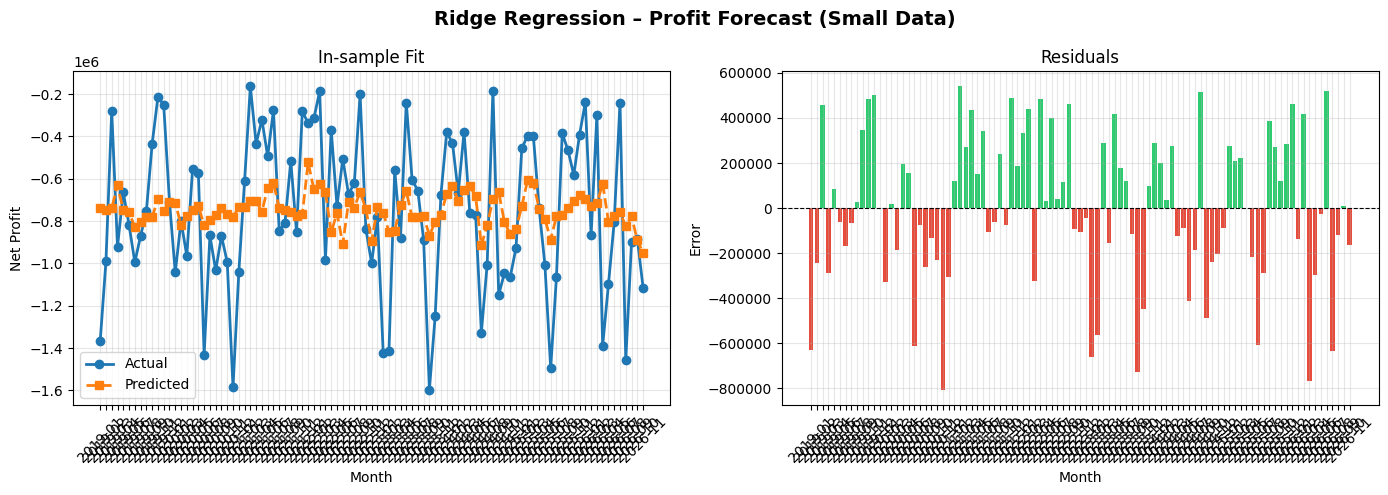

✅ Saved: ridge_evaluation.png


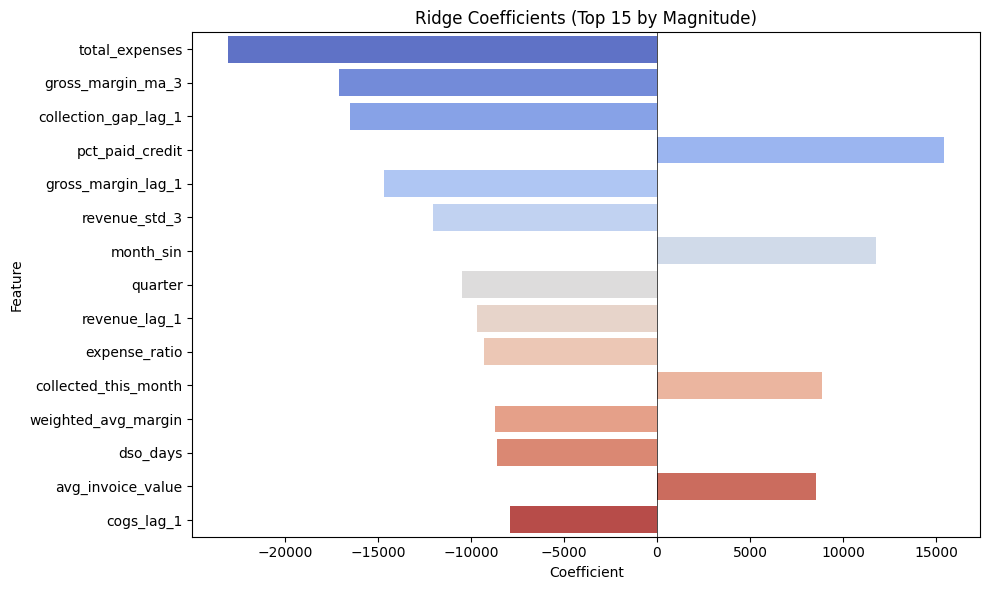


📊 Top Coefficients:
             Feature   Coefficient
      total_expenses -23058.353850
   gross_margin_ma_3 -17117.758278
collection_gap_lag_1 -16520.542997
     pct_paid_credit  15446.869967
  gross_margin_lag_1 -14657.792507
       revenue_std_3 -12027.288625
           month_sin  11759.522710
             quarter -10486.585016
       revenue_lag_1  -9698.814856
       expense_ratio  -9314.629777


In [15]:
"""
AuditAI – Profit Forecasting Model
====================================
XGBoost Regressor trained on the feature engineering pipeline output.
Target: next month's net profit (target_profit)
"""

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, LeaveOneOut, cross_val_score
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# Import your pipeline  (adjust path as needed)
# ─────────────────────────────────────────────────────────────────────────────


# ─────────────────────────────────────────────────────────────────────────────
# Step 1 – Run the feature pipeline
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("📦 Loading feature pipeline...")
print("=" * 60)

df = build_feature_pipeline()
print(f"\n✅ Raw shape: {df.shape}")


# ─────────────────────────────────────────────────────────────────────────────
# Step 2 – Drop leakage columns and non-features
# ─────────────────────────────────────────────────────────────────────────────
# - 'month'             → string identifier, not a signal
# - 'net_profit'        → direct component of target, causes leakage
# - 'billed_this_month' → near-duplicate of monthly_revenue
# - 'target_profit'     → the label itself
DROP_COLS = ['month', 'net_profit', 'billed_this_month', 'target_profit']

X = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
y = df['target_profit']

print(f"\n📊 Feature matrix shape : {X.shape}")
print(f"🎯 Target shape          : {y.shape}")


# ─────────────────────────────────────────────────────────────────────────────
# Step 3 – Handle NaN values
# ─────────────────────────────────────────────────────────────────────────────
nan_cols = X.columns[X.isna().any()].tolist()
if nan_cols:
    print(f"\n⚠️  Columns with NaN ({len(nan_cols)}): {nan_cols}")
    print("   Filling with column median (safe for small datasets).")
    X = X.fillna(X.median(numeric_only=True))

print(f"\n✅ NaN check passed. Final feature count: {X.shape[1]}")


# ─────────────────────────────────────────────────────────────────────────────
# Step 4 – Prepare Features and Target, Split Data
# ─────────────────────────────────────────────────────────────────────────────
# NOTE: With only 9 samples, test_size=0.2 gives ~2 test rows.
# This split is kept for structural parity; see Step 6 for LOO-CV
# which gives a more honest evaluation on small datasets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False  # shuffle=False preserves time order
)

print(f"\n📂 Train size : {X_train.shape[0]} rows")
print(f"📂 Test size  : {X_test.shape[0]} rows")


# ─────────────────────────────────────────────────────────────────────────────
# Step 5 – Build and Train the XGBoost Model
# ─────────────────────────────────────────────────────────────────────────────
# Params are conservative to reduce overfitting on small data:
# - max_depth=2   → very shallow trees (prevents memorization)
# - n_estimators=50 → fewer trees
# - subsample/colsample_bytree → row/feature sampling for regularization
params = {
    'objective'         : 'reg:squarederror',
    'max_depth'         : 2,
    'learning_rate'     : 0.05,
    'n_estimators'      : 50,
    'alpha'             : 10,        # L1 regularization
    'lambda'            : 5,         # L2 regularization
    'subsample'         : 0.8,
    'colsample_bytree'  : 0.8,
    'random_state'      : 42,
}

model = XGBRegressor(**params)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\n✅ Model trained.")


# ─────────────────────────────────────────────────────────────────────────────
# Step 6 – Evaluate Model Performance
# ─────────────────────────────────────────────────────────────────────────────
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("\n" + "=" * 40)
print("📈  Hold-out Test Set Results")
print("=" * 40)
print(f"  MAE  : {mae:,.2f}")
print(f"  RMSE : {rmse:,.2f}")
print(f"  R²   : {r2:.4f}")

# Leave-One-Out Cross-Validation (more reliable on small datasets)
loo   = LeaveOneOut()
loo_scores = cross_val_score(
    XGBRegressor(**params), X, y,
    cv=loo, scoring='neg_mean_absolute_error'
)
loo_mae = -loo_scores.mean()

print("\n" + "=" * 40)
print("🔁  Leave-One-Out CV (more reliable)")
print("=" * 40)
print(f"  LOO MAE  : {loo_mae:,.2f}")
print(f"  LOO Std  : {(-loo_scores).std():,.2f}")
print("=" * 40)

# Actual vs Predicted table
results_df = pd.DataFrame({
    'Month'    : df['month'].iloc[y_test.index].values,
    'Actual'   : y_test.values,
    'Predicted': y_pred,
    'Error'    : y_test.values - y_pred,
})
print("\n📋 Actual vs Predicted:")
print(results_df.to_string(index=False))


# ─────────────────────────────────────────────────────────────────────────────
# Step 7 – Plot: Actual vs Predicted
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("AuditAI – Profit Forecast Evaluation", fontsize=14, fontweight='bold')

# Left: line plot
ax1 = axes[0]
ax1.plot(results_df['Month'], results_df['Actual'],    marker='o', label='Actual',    linewidth=2)
ax1.plot(results_df['Month'], results_df['Predicted'], marker='s', label='Predicted', linewidth=2, linestyle='--')
ax1.set_title("Actual vs Predicted Net Profit")
ax1.set_xlabel("Month")
ax1.set_ylabel("Net Profit")
ax1.legend()
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# Right: residuals
ax2 = axes[1]
ax2.bar(results_df['Month'], results_df['Error'], color=['#e74c3c' if e < 0 else '#2ecc71' for e in results_df['Error']])
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title("Residuals (Actual − Predicted)")
ax2.set_xlabel("Month")
ax2.set_ylabel("Error")
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("evaluation_plot.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: evaluation_plot.png")


# ─────────────────────────────────────────────────────────────────────────────
# Step 8 – Plot Feature Importance
# ─────────────────────────────────────────────────────────────────────────────
importance_df = pd.DataFrame({
    'feature'   : X.columns,
    'importance': model.feature_importances_,
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
plt.title("Top 15 Feature Importances (XGBoost – F-score)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: feature_importance.png")

print("\n" + importance_df.to_string(index=False))


# ─────────────────────────────────────────────────────────────────────────────
# Step 9 – Visualize XGBoost Decision Tree
# ─────────────────────────────────────────────────────────────────────────────
plt.figure(figsize=(20, 8))
xgb.plot_tree(model, num_trees=0, rankdir='LR')
plt.title("XGBoost Tree #0")
plt.tight_layout()
plt.savefig("xgboost_tree.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: xgboost_tree.png")

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# ──────────────────────────────────────────────────────────────────
# 1. Load your data (assuming df already exists from pipeline)
# ──────────────────────────────────────────────────────────────────
# df = Revenue_Features()   # or whatever returns the full dataframe
# For clarity, we explicitly select only these revenue features:

df = build_feature_pipeline()  # Ensure df is defined before selecting features

REVENUE_FEATURES = [
    'revenue_lag_1',
    'revenue_lag_3',
    'revenue_growth_mom',
    'revenue_ma_3',
    'revenue_ma_6',
    'revenue_std_3',
    'month_sin',
    'month_cos',
    'is_year_end'
]

# Ensure columns exist (drop any that don't)
available_features = [col for col in REVENUE_FEATURES if col in df.columns]
X = df[available_features].copy()
y = df['monthly_revenue'].shift(-1).rename('target')

# ──────────────────────────────────────────────────────────────────
# 2. Drop rows with NaN (target last row + any lag NaNs)
# ──────────────────────────────────────────────────────────────────
valid = y.notna() & X.notna().all(axis=1)
X = X[valid]
y = y[valid]

# ──────────────────────────────────────────────────────────────────
# 3. Chronological train/test split (last 20% for test)
# ──────────────────────────────────────────────────────────────────
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# ──────────────────────────────────────────────────────────────────
# 4. Train XGBoost
# ──────────────────────────────────────────────────────────────────
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    max_depth=3,
    learning_rate=0.05,
    n_estimators=100,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)

# ──────────────────────────────────────────────────────────────────
# 5. Evaluate
# ──────────────────────────────────────────────────────────────────
y_pred = model.predict(X_test)
mape = mean_absolute_percentage_error(y_test, y_pred)
accuracy = max(0, 100 * (1 - mape))

print(f"MAE : {mean_absolute_error(y_test, y_pred):,.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):,.2f}")
print(f"R²  : {r2_score(y_test, y_pred):.4f}")
print(f"MAPE: {mape * 100:.2f}%")
print(f"Accuracy: {accuracy:.2f}%")

# ──────────────────────────────────────────────────────────────────
# 6. Predict next month's revenue (using latest feature row)
# ──────────────────────────────────────────────────────────────────
latest_features = X.iloc[-1:].copy()
next_month_revenue = model.predict(latest_features)[0]
print(f"\nPredicted next month revenue: {next_month_revenue:,.2f}")

🚀 Running feature engineering pipeline...
✅ Revenue Features:
      month      total  revenue_growth_mom   revenue_ma_3  revenue_std_3
91  2026-08  128500.42           -0.432796  168591.266667   51409.308609
92  2026-09  159971.04            0.244907  171674.000000   50061.721530
93  2026-10  630960.90            2.944220  306477.453333  281451.115385
94  2026-11   77073.19           -0.877848  289335.043333  298746.017281
95  2026-12   66490.96           -0.137301  258175.016667  322885.400734

✅ COGS & Expenses Features:
      month  monthly_revenue  total_cogs  cogs_to_revenue_ratio  expense_ratio
91  2026-08        128500.42    64726.13               0.503704       2.365259
92  2026-09        159971.04    86128.72               0.538402       9.580231
93  2026-10        630960.90   309254.95               0.490133       1.933961
94  2026-11         77073.19    39792.10               0.516290      11.944478
95  2026-12         66490.96    34576.00               0.520011      17.2610